In [1]:
%load_ext autoreload
%autoreload 2

from eeg_toolkit import (
    load_config,
    extract_mean_amplitudes,
    run_paired_tests,
    plot_results,
)

cfg = load_config('../../../configs/eye_eeg_simul.yaml')
cfg_erp = load_config('../../../configs/erp_analysis.yaml')

print("Setup OK")

Setup OK


In [2]:
# ROIs and time windows committed from notebook 02 exploration
rois = {
    'posterior_left':  ['P3', 'P7', 'O1'],
    'posterior_right': ['P4', 'P8', 'O2'],
    'posterior_mid':   ['Pz', 'Oz'],
}

time_windows = {
    'early': [0.20, 0.30],
    'late':  [0.30, 0.50],
}

df = extract_mean_amplitudes(
    cfg, window_name='cue',
    rois=rois,
    time_windows=time_windows,
    conditions=['spatial', 'symbolic'],
    save_csv=True,
    verbose=True,
)

df.head(12)

[find_subjects] excluded 8 subject(s): ['subj13', 'subj15', 'subj16', 'subj17', 'subj2', 'subj20', 'subj28', 'subj7']

Extracted 360 rows from 30 subjects.
   ROIs: ['posterior_left', 'posterior_right', 'posterior_mid']
   Time windows: ['early', 'late']
   Conditions: ['spatial', 'symbolic']
   saved: mean_amplitudes_cue.csv


,subject,window,roi,channels,condition,time_window,tmin,tmax,mean_amp_uv
0,subj3,cue,posterior_left,"P3,P7,O1",spatial,early,0.2,0.3,1.411966
1,subj3,cue,posterior_left,"P3,P7,O1",spatial,late,0.3,0.5,0.730727
2,subj3,cue,posterior_right,"P4,P8,O2",spatial,early,0.2,0.3,2.431976
3,subj3,cue,posterior_right,"P4,P8,O2",spatial,late,0.3,0.5,3.934640
4,subj3,cue,posterior_mid,"Pz,Oz",spatial,early,0.2,0.3,1.654396
5,subj3,cue,posterior_mid,"Pz,Oz",spatial,late,0.3,0.5,2.178427
6,subj3,cue,posterior_left,"P3,P7,O1",symbolic,early,0.2,0.3,1.772478
7,subj3,cue,posterior_left,"P3,P7,O1",symbolic,late,0.3,0.5,0.748416
8,subj3,cue,posterior_right,"P4,P8,O2",symbolic,early,0.2,0.3,2.607658
9,subj3,cue,posterior_right,"P4,P8,O2",symbolic,late,0.3,0.5,3.989018


In [4]:
results = run_paired_tests(
    df,
    contrasts=('spatial', 'symbolic'),
    cfg=cfg, window_name='cue',
    save_csv=True, verbose=True,
)


Paired tests: 1 contrast(s), FDR across 6 tests total.

           contrast             roi time_window   tmin   tmax  n  mean_diff_uv  sd_diff_uv  cohens_d      t    p_t  p_t_fdr  sig_t_fdr        w    p_w  p_w_fdr  sig_w_fdr
spatial_vs_symbolic  posterior_left       early 0.2000 0.3000 30        0.1473      0.7001    0.2104 1.1523 0.2586   0.3103      False 171.0000 0.2129   0.3194      False
spatial_vs_symbolic  posterior_left        late 0.3000 0.5000 30        0.2223      0.6458    0.3442 1.8853 0.0694   0.1389      False 144.0000 0.0699   0.1398      False
spatial_vs_symbolic   posterior_mid       early 0.2000 0.3000 30        0.1580      0.7182    0.2200 1.2049 0.2380   0.3103      False 181.0000 0.2988   0.3586      False
spatial_vs_symbolic   posterior_mid        late 0.3000 0.5000 30        0.3365      0.6082    0.5534 3.0308 0.0051   0.0300       True  93.0000 0.0032   0.0193       True
spatial_vs_symbolic posterior_right       early 0.2000 0.3000 30        0.1030      0.66

[find_subjects] excluded 8 subject(s): ['subj13', 'subj15', 'subj16', 'subj17', 'subj2', 'subj20', 'subj28', 'subj7']


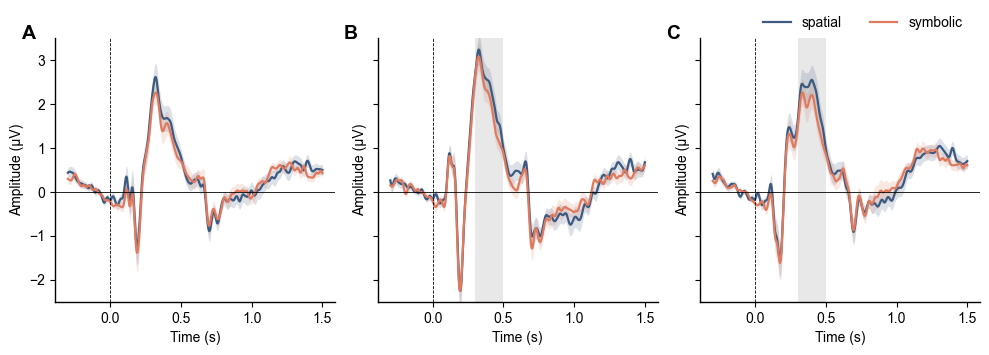

In [9]:
from pathlib import Path

# Custom color palette (any matplotlib-compatible color works: hex, name, rgb)
colors = {
    'spatial':  '#3D5A80',   # deep blue
    'symbolic': '#E07A5F',   # coral
}

fig = plot_results(
    cfg,                              # main config
    window_name='cue',                # 'cue' or 'trial'
    rois=rois,                        # dict {roi_name: [channels]}
    conditions=['spatial', 'symbolic'],            # tuple (cond_a, cond_b)
    stats_df=results,                 # DataFrame from run_paired_tests; None to skip shading
    colors=colors,                    # condition -> color; None for default teal/coral
    ylim=(-2.5, 3.5),                 # y-axis range in µV; None for auto
    xlim=(-0.2, 1.5),                 # x-axis range in seconds; None for full epoch
    figsize=(10, 3.5),                # (width, height) in inches; None for auto
    ncols=3,                          # panels per row; None = min(n_rois, 3)
    font='Arial',                     # font family (falls back if not installed)
    dpi=300,                          # output resolution
    save_path=None,                   # Path object to save .png + .tiff; None to display only
    alpha_fdr=0.05,                   # FDR threshold for shading sig windows
    verbose=True,
)

fig